In [7]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from scipy.spatial.distance import cosine
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import torch.nn.functional as F
import random 

In [8]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [103]:
# tokens start from 1
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=1):
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), 1))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                self.X[ii,jj] = \
                ord(data[ii+jj])-64
      
            self.y[ii] = \
                ord(data[ii+jj+1])-64

        self.X = tnsr(self.X).long()
        self.y = tnsr(self.y).long()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [104]:
def path_finder_loss(y_pred, decoder_output, y_target, decoder_target):
    ce1 = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_target.view(-1))
    ce2 = F.cross_entropy(decoder_output.view(-1, decoder_output.size(-1)), decoder_target.view(-1))

    return (ce1+ce2)/2

In [258]:
class RNNEncoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True, nonlinearity='relu')
        self.linear = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, h=None):
        embedded = self.embedding(x)
        out, h = self.rnn(embedded, h)
        out = self.linear(out[:,-1,:])

        return out, h  
    
class RNNDecoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True, nonlinearity='relu')
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x, h):
        embedded = self.embedding(x)
        out, _ = self.rnn(embedded, h)
        return self.fc(out) 
    
class RNNAutoencoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.encoder = RNNEncoder(vocab_size, embedding_dim, hidden_size)
        self.decoder = RNNDecoder(vocab_size, embedding_dim, hidden_size)
    
    def forward(self, x, decoder_input, h=None):
        next_token, h = self.encoder(x, h)
        decoder_output = self.decoder(decoder_input, h)
        return next_token, decoder_output, h

In [259]:
### initial training ###
total_samples = 30000
working_memory = 1
short_term_memory = 5
hidden_size = 50
vocab_size = 8
embedding_dim = 5
lr = 1e-3
test_acc = []
test_acc_decoder = []

model = RNNAutoencoder(vocab_size, embedding_dim, hidden_size)
optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95, weight_decay=1e-8)
criterion = path_finder_loss

data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)

data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

total = 0
correct = np.zeros(1000,dtype=float)
decoder_correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    decoder_input = torch.cat([torch.zeros((1, 1), dtype=torch.long), X[:, :-1]], dim=1)
    decoder_target = X.flip(1)

    optimizer.zero_grad()

    if total == 0:
        y_pred, decoder_output, h = model(X, decoder_input)
    else:
        y_pred, decoder_output, h = model(X, decoder_input, hidden)

    loss = criterion(y_pred[0], decoder_output[0], y[0], decoder_target[0])     
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        hidden = h.clone()
        total += 1

        if y[0] == y_pred[0].argmax():
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        if torch.sum(decoder_output.argmax(2) == decoder_target)==short_term_memory:
                decoder_correct[total%1000] = 1
        else:
            decoder_correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        test_acc_decoder.append(
            np.sum(decoder_correct)/total if total<1000 else np.sum(decoder_correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}, decoder accuracy: {test_acc_decoder[-1]:.4f}')
    
        

Iter : 1001, loss: 2.1465, accuracy: 0.2960, decoder accuracy: 0.0000
Iter : 2001, loss: 1.7181, accuracy: 0.5650, decoder accuracy: 0.0890
Iter : 3001, loss: 0.7141, accuracy: 0.6450, decoder accuracy: 0.4860
Iter : 4001, loss: 0.7666, accuracy: 0.6730, decoder accuracy: 0.6740
Iter : 5001, loss: 1.4645, accuracy: 0.6670, decoder accuracy: 0.8030
Iter : 6001, loss: 1.5912, accuracy: 0.6530, decoder accuracy: 0.9340
Iter : 7001, loss: 0.9147, accuracy: 0.6690, decoder accuracy: 0.9810
Iter : 8001, loss: 0.7778, accuracy: 0.6880, decoder accuracy: 0.9070
Iter : 9001, loss: 0.7191, accuracy: 0.6650, decoder accuracy: 0.9670
Iter : 10001, loss: 0.8901, accuracy: 0.6690, decoder accuracy: 0.9810
Iter : 11001, loss: 1.2777, accuracy: 0.6690, decoder accuracy: 0.9770
Iter : 12001, loss: 0.8005, accuracy: 0.6700, decoder accuracy: 0.9680
Iter : 13001, loss: 0.8020, accuracy: 0.6750, decoder accuracy: 1.0000
Iter : 14001, loss: 1.0000, accuracy: 0.6860, decoder accuracy: 0.9970
Iter : 15001, l

In [260]:
### initial training ###
total_samples = 100
data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)

# data_set = Dataset_converter(data, working_memory, short_term_memory)
# train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

total = 0
prev_h = torch.ones(1,1,hidden_size)
dis = []
# X_hat = torch.zeros(vocab_size,dtype=torch.float32)
x_hat=torch.tensor([[1]])

for ii in range(total_samples):

    with torch.no_grad():
        if total==0:
            x_hat, h = model.encoder(x_hat)
        else:
            x_hat, h = model.encoder(x_hat, h=h)
            # break

        print('train', cosine(prev_h[0][0], h[0][0]), tokens[x_hat.argmax()-1])
        X_hat_prob = torch.nn.functional.softmax(x_hat, dim=1)
        # fix_seeds(10)
        dist_categ = torch.distributions.Categorical(probs=X_hat_prob.reshape(-1))
        idx = dist_categ.sample()

        # x_hat = torch.zeros(vocab_size,dtype=torch.float32)
        # X_hat[len(tokens):] = noise
        x_hat = torch.tensor([[idx]])
        # dis.append(cosine(prev_h[0][0], h[0][0]))
        
        total += 1
        prev_h = h.clone()


train 0.4904053129462177 B
train 0.4980272206521428 B
train 0.6323036006543274 G
train 0.7826250500834564 A
train 0.9371910233008589 D
train 0.47461209210111166 D
train 0.573835695481866 G
train 0.8082169140239829 F
train 0.9738539604964386 F
train 0.4969234978313828 D
train 0.5084037760737605 G
train 0.8218906054387662 F
train 0.7021093505363718 B
train 0.5720009442172636 B
train 0.6529823010530751 G
train 0.9196350669351157 B
train 0.8616726507532229 A
train 0.6369853616855564 C
train 0.8021626735648903 G
train 0.985635587263361 A
train 0.9585028805224425 D
train 0.7375743528976852 F
train 0.6684382785626355 G
train 0.8519169148881393 A
train 0.9213799448995147 E
train 0.4911317134428469 D
train 0.7050017880359218 G
train 0.8870554751551444 F
train 0.9620907955353525 E
train 0.4362824760886378 E
train 0.5687005773475553 G
train 0.8154147017813873 A
train 0.8893517591042108 C
train 0.5864855121098949 A
train 0.7206597475067187 G
train 0.9001420197184741 A
train 0.8347895893406834 B
tr

In [263]:
x_hat

tensor([[-5.1712,  8.6213,  2.6427,  2.8053, -4.1517, -2.0168,  1.4503, -3.7625]])

In [262]:
### initial training ###
total_samples = 300
data = get_sequence(total_samples, n_community, n_members, train_percent=1.0)

data_set = Dataset_converter(data, working_memory, short_term_memory=1)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

total = 0
prev_h = torch.ones(1,1,hidden_size)
hidden = []
token = []

for X, y in train_loader:

    with torch.no_grad():
        if total==0:
            x_hat, h = model.encoder(X)
        else:
            x_hat, h = model.encoder(X, h=h)
            print('train', cosine(prev_h[0][0], h[0][0]), tokens[y[0][0]-1])

        hidden.append(
            h[0][0].detach().numpy()
        )
        token.append(tokens[y[0][0]-1])

        prev_h = h.clone()
        
        total += 1

train 0.5228486412574394 A
train 0.6818963439763528 G
train 0.8728135243815873 F
train 0.8699933103263632 D
train 0.5592384770649375 E
train 0.8026054646769782 G
train 0.930755763969259 D
train 0.9639534583195343 E
train 0.6053557943687209 F
train 0.7017342397864037 G
train 0.9649333832268583 A
train 0.8321305681337008 C
train 0.6870387661078292 B
train 0.8150362814594363 G
train 0.944427797925149 F
train 0.9678513503902553 D
train 0.4936828433629471 E
train 0.7298768769715276 G
train 0.9507885668698307 D
train 0.9176712421916676 E
train 0.6054105694978894 F
train 0.7150611671880709 G
train 0.9655419853394692 D
train 0.9286270441582958 F
train 0.46742593661636944 E
train 0.6681344414507502 G
train 0.8043051054426481 D
train 0.9479860021994468 F
train 0.451294198200496 E
train 0.6492162534893466 G
train 0.8166655318194761 D
train 0.9472898246751631 F
train 0.44926231398798 E
train 0.6482357681887686 G
train 0.8178221880538624 D
train 0.9471411950870001 F
train 0.44953459663861184 E
trai

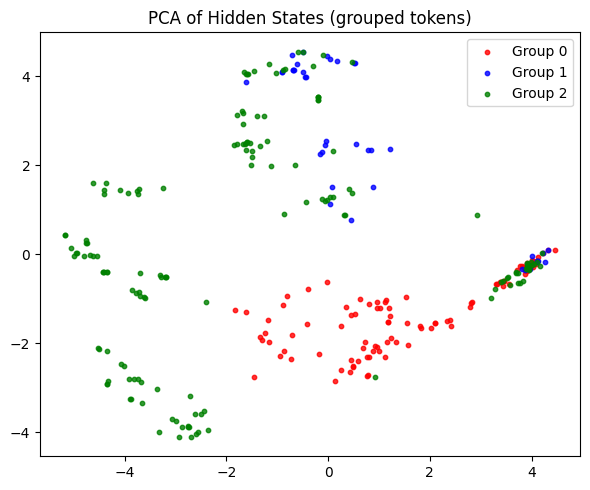

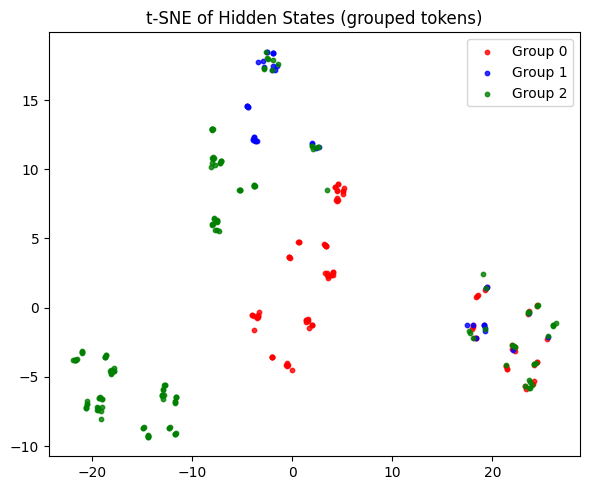

In [257]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Your data
hidden_states = np.array(hidden)  # shape (num_points, hidden_dim)
tokens_ = np.array(token)         # shape (num_points,)

assert hidden_states.shape[0] == len(tokens_), "Mismatch: hidden_states and tokens must have same length"

# Define groups by letters
group0 = {'A', 'B', 'C'}
group1 = {'D'}
group2 = {'E', 'F', 'G'}

def map_to_group(tok):
    if tok in group0:
        return 0
    elif tok in group1:
        return 1
    elif tok in group2:
        return 2
    else:
        return -1  # unknown

labels = np.array([map_to_group(t) for t in tokens_])

# Fixed colors for groups
group_colors = {0: 'red', 1: 'blue', 2: 'green', -1: 'gray'}
colors = [group_colors[g] for g in labels]

# PCA
pca = PCA(n_components=2)
hidden_pca = pca.fit_transform(hidden_states)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
hidden_tsne = tsne.fit_transform(hidden_states)

# Plot
def plot_embedding(embedding, title):
    plt.figure(figsize=(6, 5))
    for g, color in group_colors.items():
        idx = labels == g
        if np.any(idx):
            plt.scatter(
                embedding[idx, 0],
                embedding[idx, 1],
                c=color,
                label=f'Group {g}',
                s=10,
                alpha=0.8
            )
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_embedding(hidden_pca, "PCA of Hidden States (grouped tokens)")
plot_embedding(hidden_tsne, "t-SNE of Hidden States (grouped tokens)")
